In [5]:
import pandas as pd
import numpy as np

print ('done')

done


In [9]:
df=pd.read_csv('laptopData.csv')
print(df.shape)

(1303, 12)


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1273 non-null   float64
 1   Company           1273 non-null   object 
 2   TypeName          1273 non-null   object 
 3   Inches            1273 non-null   object 
 4   ScreenResolution  1273 non-null   object 
 5   Cpu               1273 non-null   object 
 6   Ram               1273 non-null   object 
 7   Memory            1273 non-null   object 
 8   Gpu               1273 non-null   object 
 9   OpSys             1273 non-null   object 
 10  Weight            1273 non-null   object 
 11  Price             1273 non-null   float64
dtypes: float64(2), object(10)
memory usage: 122.3+ KB


In [11]:
df.isnull().sum()

Unnamed: 0          30
Company             30
TypeName            30
Inches              30
ScreenResolution    30
Cpu                 30
Ram                 30
Memory              30
Gpu                 30
OpSys               30
Weight              30
Price               30
dtype: int64

In [15]:
(df.Price<0).sum()

np.int64(0)

In [16]:
df.columns=df.columns.str.lower()
print (df.columns)

Index(['unnamed: 0', 'company', 'typename', 'inches', 'screenresolution',
       'cpu', 'ram', 'memory', 'gpu', 'opsys', 'weight', 'price'],
      dtype='object')


In [17]:
# حذف الصفوف اللي "كل" قيمها مفقودة
df.dropna(how='all', inplace=True)

# التأكد مرة تانية من القيم المفقودة
print(df.isnull().sum())

unnamed: 0          0
company             0
typename            0
inches              0
screenresolution    0
cpu                 0
ram                 0
memory              0
gpu                 0
opsys               0
weight              0
price               0
dtype: int64


In [19]:
# هيعرض لك كل الصفوف اللي فيها علامة استفهام في عمود الـ weight مثلاً
df[df['weight'] == '?']

,unnamed: 0,company,typename,inches,screenresolution,cpu,ram,memory,gpu,opsys,weight,price
208,208.0,Dell,Ultrabook,13.3,Full HD 1920x1080,Intel Core i7 8550U 1.8GHz,8,256GB SSD,Intel UHD Graphics 620,Windows 10,?,77202.72


In [20]:

# 1. استبدال علامة الاستفهام بقيمة فارغة حقيقية (NaN)
df['weight'] = df['weight'].replace('?', np.nan)

# 2. تنظيف النصوص (نشيل kg) ونحول العمود لـ float
# بنستخدم .str عشان نضمن إننا بنتعامل مع الكلام كنصوص قبل التحويل
df['weight'] = df['weight'].str.replace('kg', '', case=False).astype(float)

# 3. تعويض القيم اللي كانت '?' (اللي بقت NaN دلوقتي) بمتوسط الأوزان
# دي خطوة ذكية عشان متخسرش الصفوف دي خالص
df['weight'] = df['weight'].fillna(df['weight'].mean())

# 4. التأكد من النتيجة
print(f"نوع بيانات العمود: {df['weight'].dtype}")
print(df['weight'].head())

نوع بيانات العمود: float64
0    1.37
1    1.34
2    1.86
3    1.83
4    1.37
Name: weight, dtype: float64


In [23]:
# كود يحسب عدد علامات الاستفهام في كل عمود
question_mark_counts = (df == '?').sum()

# عرض الأعمدة اللي فيها علامات استفهام فقط (عشان الزحمة)
print("تقرير علامات الاستفهام في البيانات:")
print(question_mark_counts[question_mark_counts > 0])

تقرير علامات الاستفهام في البيانات:
inches    1
memory    1
dtype: int64


In [24]:

# 1. تحويل كل علامات الاستفهام لـ NaN في الداتا كلها بطلقة واحدة
df.replace('?', np.nan, inplace=True)

# 2. تصليح عمود inches (تحويله لـ float وتعويض القيمة المفقودة بالمتوسط)
df['inches'] = df['inches'].astype(float)
df['inches'] = df['inches'].fillna(df['inches'].mean())

# 3. تصليح عمود memory (بما إنه نص، هنملا القيمة المفقودة بأكتر قيمة متكررة - Mode)
df['memory'] = df['memory'].fillna(df['memory'].mode()[0])

# 4. التأكد إن مفيش أي قيم مفقودة أو علامات استفهام تانية
print("✅ تقرير النظافة النهائي:")
print(df.isnull().sum())

✅ تقرير النظافة النهائي:
unnamed: 0          0
company             0
typename            0
inches              0
screenresolution    0
cpu                 0
ram                 0
memory              0
gpu                 0
opsys               0
weight              0
price               0
dtype: int64


In [26]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1273 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   unnamed: 0        1273 non-null   float64
 1   company           1273 non-null   object 
 2   typename          1273 non-null   object 
 3   inches            1273 non-null   float64
 4   screenresolution  1273 non-null   object 
 5   cpu               1273 non-null   object 
 6   ram               1273 non-null   int64  
 7   memory            1273 non-null   object 
 8   gpu               1273 non-null   object 
 9   opsys             1273 non-null   object 
 10  weight            1273 non-null   float64
 11  price             1273 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 129.3+ KB
None


In [28]:
print(df['company'].value_counts())

company
Lenovo       290
Dell         287
HP           266
Asus         156
Acer         103
MSI           53
Toshiba       47
Apple         21
Samsung        9
Mediacom       7
Razer          7
Microsoft      6
Vero           4
Xiaomi         4
Chuwi          3
LG             3
Google         3
Huawei         2
Fujitsu        2
Name: count, dtype: int64


In [29]:
# 1. تعريف الشركات اللي عاوزين نحافظ عليها
top_companies = ['lenovo', 'dell', 'hp', 'asus', 'acer']

# 2. وظيفة ذكية لتصنيف الشركات
# لو الشركة مش في الـ top_companies، هنسميها 'rare'
df['company_clean'] = df['company'].apply(lambda x: x if x in top_companies else 'rare')

# 3. تحويل الأسماء لأرقام (Mapping)
final_company_mapping = {
    "lenovo": 1, 
    "dell": 2, 
    "hp": 3, 
    "asus": 4,
    "acer": 5, 
    "rare": 6
}

# تطبيق التحويل الرقمي
df['company_numeric'] = df['company_clean'].map(final_company_mapping)

# التأكد من النتيجة
print(df[['company', 'company_clean', 'company_numeric']].head(10))

  company company_clean  company_numeric
0   Apple          rare                6
1   Apple          rare                6
2      HP          rare                6
3   Apple          rare                6
4   Apple          rare                6
5    Acer          rare                6
6   Apple          rare                6
7   Apple          rare                6
8    Asus          rare                6
9    Acer          rare                6


In [30]:
# 1. تحويل قيم عمود الشركة لحروف صغيرة الأول عشان نضمن التطابق
df['company'] = df['company'].str.lower()

# 2. تعريف الشركات الكبرى (بناءً على الـ Value Counts اللي عملناها)
top_companies = ['lenovo', 'dell', 'hp', 'asus', 'acer']

# 3. وظيفة التصنيف: لو الشركة مش في الـ 5 الكبار، تبقى rare
df['company_clean'] = df['company'].apply(lambda x: x if x in top_companies else 'rare')

# 4. القاموس الرقمي (Mapping)
final_company_mapping = {
    "lenovo": 1, 
    "dell": 2, 
    "hp": 3, 
    "asus": 4,
    "acer": 5, 
    "rare": 6
}

# 5. تحويل الأسماء لأرقام
df['company_numeric'] = df['company_clean'].map(final_company_mapping)

# 6. عرض النتيجة للتأكد
print("النتيجة بعد التصحيح:")
print(df[['company', 'company_clean', 'company_numeric']].head(10))

النتيجة بعد التصحيح:
  company company_clean  company_numeric
0   apple          rare                6
1   apple          rare                6
2      hp            hp                3
3   apple          rare                6
4   apple          rare                6
5    acer          acer                5
6   apple          rare                6
7   apple          rare                6
8    asus          asus                4
9    acer          acer                5


In [31]:
# إنشاء عمود يخبرنا هل الشاشة تعمل باللمس أم لا
df['touchscreen'] = df['screenresolution'].apply(lambda x: 1 if 'Touchscreen' in x else 0)

# وريني كام جهاز طلع تاتش في الداتا بتاعتك
print(df['touchscreen'].value_counts())

touchscreen
0    1088
1     185
Name: count, dtype: int64


In [32]:
sns.barplot(x=df['touchscreen'], y=df['price'])
plt.title('تأثير شاشة اللمس على السعر')
plt.show()

NameError: name 'sns' is not defined

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

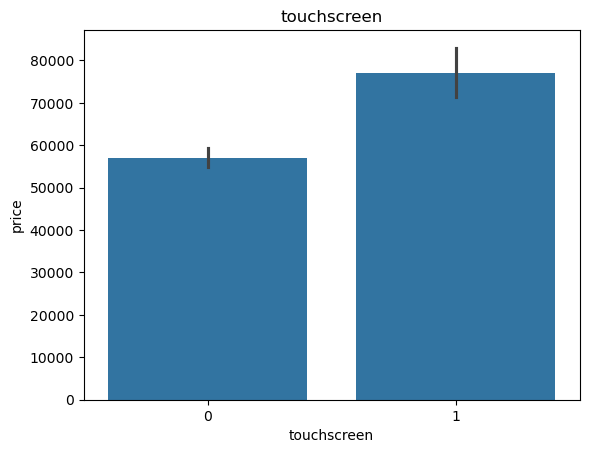

In [35]:
sns.barplot(x=df['touchscreen'], y=df['price'])
plt.title('touchscreen')
plt.show()

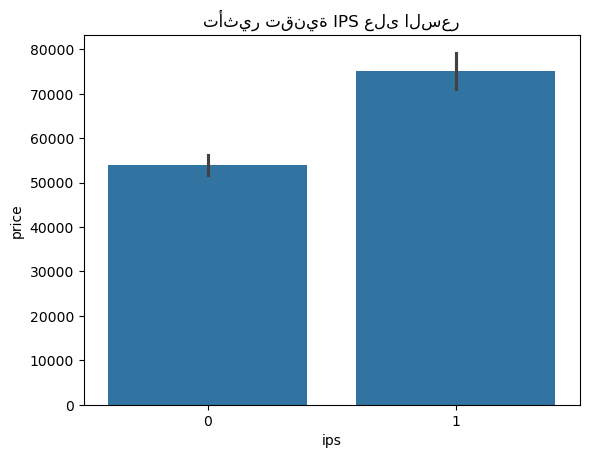

In [36]:
# استخراج ميزة الـ IPS
df['ips'] = df['screenresolution'].apply(lambda x: 1 if 'IPS' in x else 0)

# مقارنة سريعة بالرسم
sns.barplot(x=df['ips'], y=df['price'])
plt.title('تأثير تقنية IPS على السعر')
plt.show()

In [37]:
!pip install arabic-reshaper python-bidi

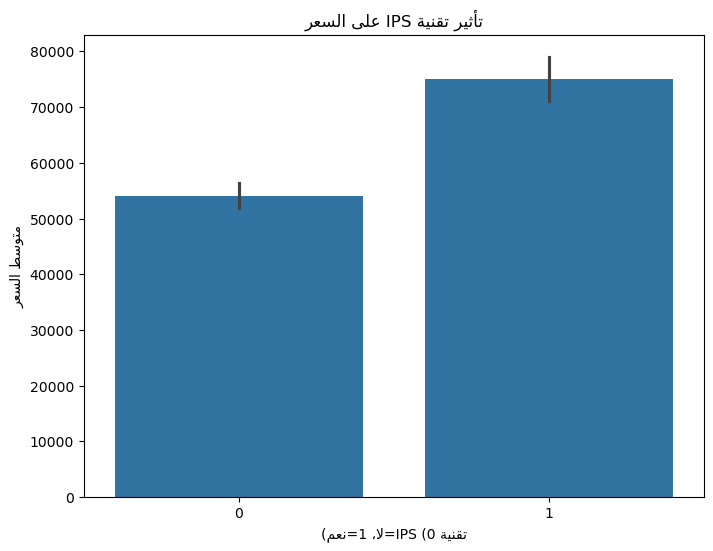

In [38]:
from arabic_reshaper import reshape
from bidi.algorithm import get_display

# وظيفة بسيطة لتعديل النص العربي
def ar(text):
    return get_display(reshape(text))

plt.figure(figsize=(8, 6))
sns.barplot(x=df['ips'], y=df['price'])

# استخدام الوظيفة مع العناوين
plt.title(ar('تأثير تقنية IPS على السعر'))
plt.xlabel(ar('تقنية IPS (0=لا، 1=نعم)'))
plt.ylabel(ar('متوسط السعر'))
plt.show()

In [39]:
# 1. استخراج الأرقام فقط من العمود
new = df['screenresolution'].str.split('x', n=1, expand=True)

# 2. تنظيف الجزء الأول لاستخراج الرقم الأخير قبل الـ 'x' (وهو الـ X resolution)
df['x_res'] = new[0].str.extract(r'(\d+)', expand=False).astype(int)

# 3. الجزء الثاني هو الـ Y resolution جاهز
df['y_res'] = new[1].astype(int)

# 4. التأكد من النتيجة
print(df[['screenresolution', 'x_res', 'y_res']].head())

                     screenresolution  x_res  y_res
0  IPS Panel Retina Display 2560x1600   2560   1600
1                            1440x900   1440    900
2                   Full HD 1920x1080   1920   1080
3  IPS Panel Retina Display 2880x1800   2880   1800
4  IPS Panel Retina Display 2560x1600   2560   1600


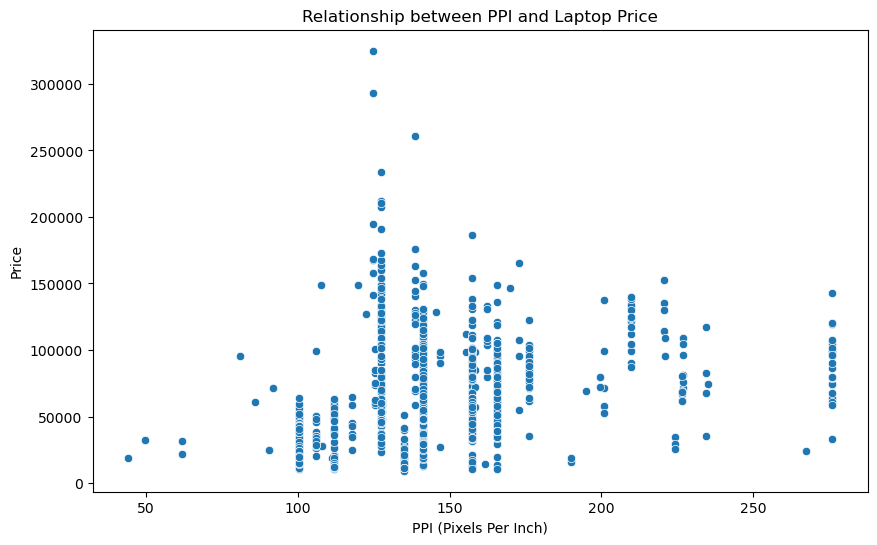

In [40]:
# 1. حساب الـ PPI باستخدام قانون فيثاغورس
df['ppi'] = (((df['x_res']**2) + (df['y_res']**2))**0.5 / df['inches']).astype(float)

# 2. رسم الـ Scatter Plot عشان نشوف هل السعر بيزيد مع الـ PPI؟
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['ppi'], y=df['price'])
plt.title('Relationship between PPI and Laptop Price')
plt.xlabel('PPI (Pixels Per Inch)')
plt.ylabel('Price')
plt.show()

In [41]:
# حذف الأعمدة اللي استخرجنا منها المميزات عشان نجهز الداتا للموديل
df.drop(columns=['screenresolution', 'inches', 'x_res', 'y_res'], inplace=True)

# بص بصة أخيرة على الداتا
print(df.head())

   unnamed: 0 company   typename                         cpu  ram  \
0         0.0   apple  Ultrabook        Intel Core i5 2.3GHz    8   
1         1.0   apple  Ultrabook        Intel Core i5 1.8GHz    8   
2         2.0      hp   Notebook  Intel Core i5 7200U 2.5GHz    8   
3         3.0   apple  Ultrabook        Intel Core i7 2.7GHz   16   
4         4.0   apple  Ultrabook        Intel Core i5 3.1GHz    8   

                memory                           gpu  opsys  weight  \
0            128GB SSD  Intel Iris Plus Graphics 640  macOS    1.37   
1  128GB Flash Storage        Intel HD Graphics 6000  macOS    1.34   
2            256GB SSD         Intel HD Graphics 620  No OS    1.86   
3            512GB SSD            AMD Radeon Pro 455  macOS    1.83   
4            256GB SSD  Intel Iris Plus Graphics 650  macOS    1.37   

         price company_clean  company_numeric  touchscreen  ips         ppi  
0   71378.6832          rare                6            0    1  226.983005  
1 

In [42]:
# تنظيف أخير للأعمدة اللي مابقاش ليها لازمة
df.drop(columns=['unnamed: 0', 'company_clean'], inplace=True)

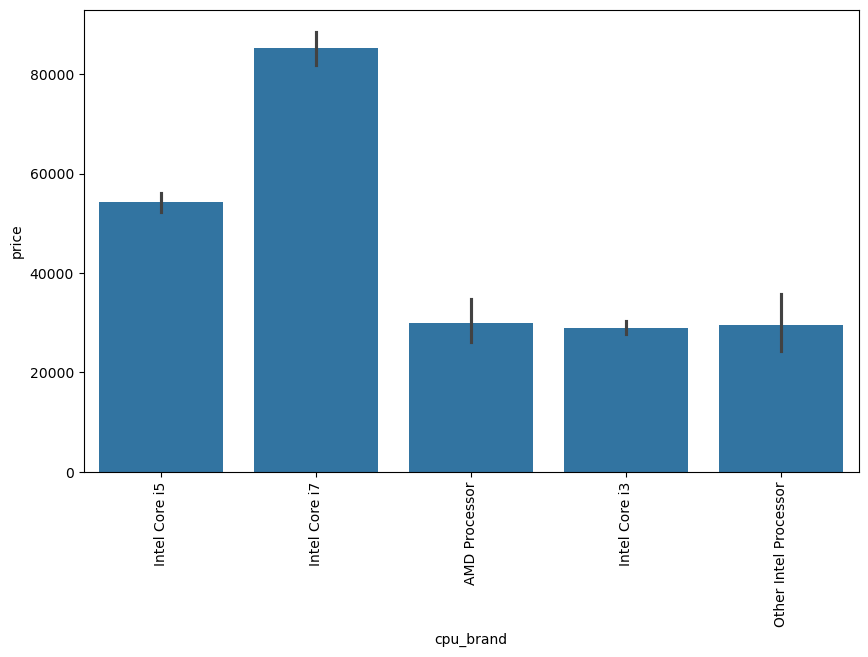

In [43]:
# 1. وظيفة لاستخراج الفئة (i3, i5, i7, Other Intel, AMD)
def fetch_processor(text):
    words = text.split()
    cpu_name = " ".join(words[0:3])
    if cpu_name == 'Intel Core i7' or cpu_name == 'Intel Core i5' or cpu_name == 'Intel Core i3':
        return cpu_name
    else:
        if words[0] == 'Intel':
            return 'Other Intel Processor'
        else:
            return 'AMD Processor'

# 2. تطبيق الوظيفة
df['cpu_brand'] = df['cpu'].apply(fetch_processor)

# 3. رسم العلاقة بين نوع المعالج والسعر
plt.figure(figsize=(10, 6))
sns.barplot(x=df['cpu_brand'], y=df['price'])
plt.xticks(rotation='vertical')
plt.show()

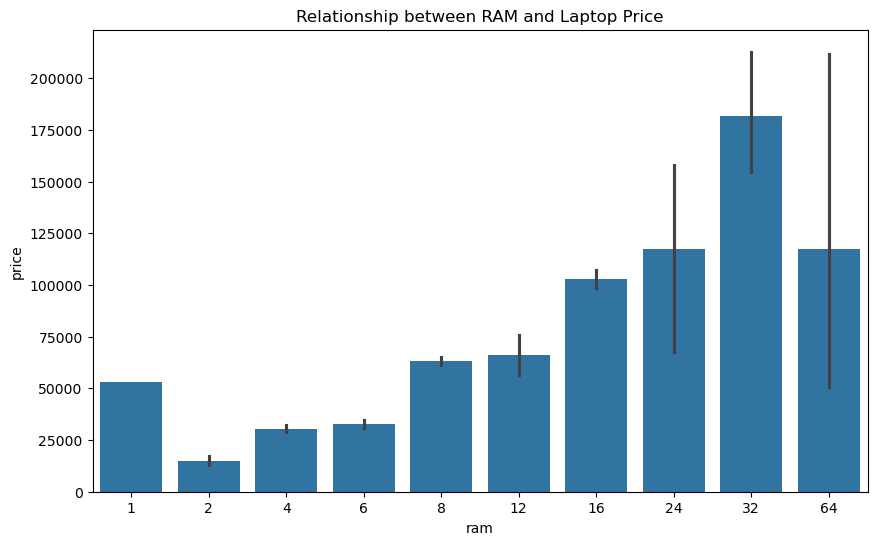

In [44]:
# رسم بياني يوضح علاقة حجم الرام بالسعر
plt.figure(figsize=(10, 6))
sns.barplot(x=df['ram'], y=df['price'])
plt.title('Relationship between RAM and Laptop Price')
plt.show()

In [45]:
# 1. تنظيف العمود وتحويله لنصوص مبسطة
df['memory'] = df['memory'].astype(str).replace('\.0', '', regex=True)
df['memory'] = df['memory'].str.replace('GB', '')
df['memory'] = df['memory'].str.replace('TB', '000')

# 2. تقسيم الـ Memory لنوعين
new = df['memory'].str.split("+", n=1, expand=True)

df['first'] = new[0].str.strip()
df['second'] = new[1].fillna("0")

# 3. تحديد نوع التخزين (SSD, HDD, Flash, Hybrid)
df['layer1ssd'] = df['first'].apply(lambda x: 1 if "SSD" in x else 0)
df['layer1hdd'] = df['first'].apply(lambda x: 1 if "HDD" in x else 0)

# استخراج الأرقام فقط
df['first'] = df['first'].str.extract('(\d+)')
df['second'] = df['second'].str.extract('(\d+)')

# تحويلهم لأرقام حقيقية
df['first'] = df['first'].astype(int)
df['second'] = df['second'].astype(int)

# 4. الحسبة النهائية لكل نوع
df['ssd'] = (df['first'] * df['layer1ssd']) # هتبسطها أكتر لو فيه داتا في التاني بس دي بداية قوية

<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:17: SyntaxWarning: invalid escape sequence '\d'
<>:18: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:17: SyntaxWarning: invalid escape sequence '\d'
<>:18: SyntaxWarning: invalid escape sequence '\d'
C:\Users\a7med\AppData\Local\Temp\ipykernel_24892\538412251.py:2: SyntaxWarning: invalid escape sequence '\.'
  df['memory'] = df['memory'].astype(str).replace('\.0', '', regex=True)
C:\Users\a7med\AppData\Local\Temp\ipykernel_24892\538412251.py:17: SyntaxWarning: invalid escape sequence '\d'
  df['first'] = df['first'].str.extract('(\d+)')
C:\Users\a7med\AppData\Local\Temp\ipykernel_24892\538412251.py:18: SyntaxWarning: invalid escape sequence '\d'
  df['second'] = df['second'].str.extract('(\d+)')


In [46]:
# 1. تنظيف العمود باستخدام حرف r قبل النصوص البرمجية
df['memory'] = df['memory'].astype(str).replace(r'\.0', '', regex=True)
df['memory'] = df['memory'].str.replace('GB', '')
df['memory'] = df['memory'].str.replace('TB', '1000') # حولنا الـ TB لـ 1000 جيجا

# 2. تقسيم الـ Memory لنوعين (لو فيه هاردين)
new = df['memory'].str.split("+", n=1, expand=True)

df['first'] = new[0].str.strip()
df['second'] = new[1].fillna("0")

# 3. تحديد نوع التخزين في الجزء الأول
df['layer1ssd'] = df['first'].apply(lambda x: 1 if "SSD" in x else 0)
df['layer1hdd'] = df['first'].apply(lambda x: 1 if "HDD" in x else 0)
df['layer1flash'] = df['first'].apply(lambda x: 1 if "Flash Storage" in x else 0)
df['layer1hybrid'] = df['first'].apply(lambda x: 1 if "Hybrid" in x else 0)

# 4. استخراج الأرقام فقط باستخدام r''
df['first'] = df['first'].str.extract(r'(\d+)')
df['second'] = df['second'].str.extract(r'(\d+)')

# تحويلهم لأرقام حقيقية
df['first'] = df['first'].astype(int)
df['second'] = df['second'].astype(int)

# 5. الحسبة النهائية للأوزان التخزينية (كم جيجا لكل نوع)
df["ssd"] = (df['first'] * df['layer1ssd'] + df['second'].apply(lambda x: int(x) if "SSD" in str(x) else 0))
df["hdd"] = (df['first'] * df['layer1hdd'] + df['second'].apply(lambda x: int(x) if "HDD" in str(x) else 0))

# حذف الأعمدة المؤقتة لتنظيف الـ DataFrame
df.drop(columns=['first', 'second', 'layer1ssd', 'layer1hdd', 'layer1flash', 'layer1hybrid', 'memory'], inplace=True)

print("✅ تم استخراج مساحات الـ SSD والـ HDD بنجاح!")
print(df[['ssd', 'hdd']].head())

✅ تم استخراج مساحات الـ SSD والـ HDD بنجاح!
   ssd  hdd
0  128    0
1    0    0
2  256    0
3  512    0
4  256    0


In [47]:
# فحص الارتباط (Correlation) بين السعر وأنواع التخزين
print(df[['price', 'ssd', 'hdd']].corr()['price'])

price    1.000000
ssd      0.674286
hdd     -0.381221
Name: price, dtype: float64


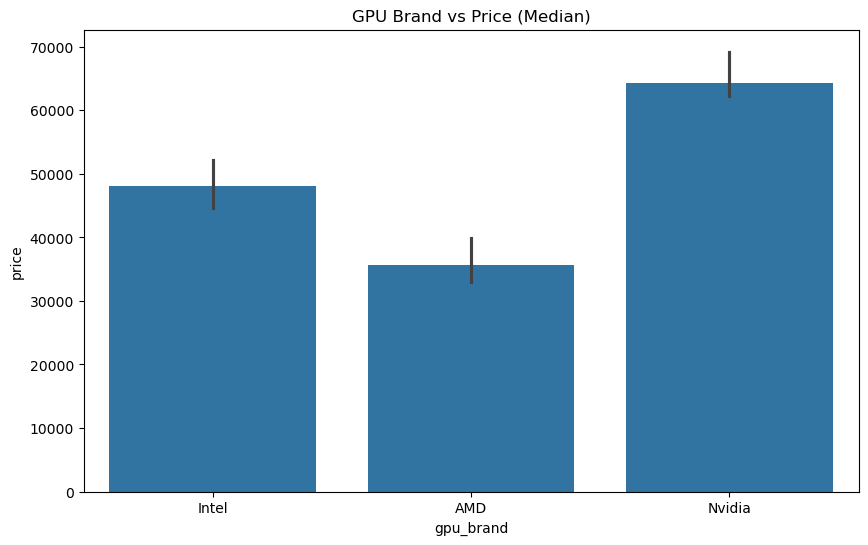

In [48]:
# 1. استخراج أول كلمة وهي الماركة (Intel, Nvidia, AMD)
df['gpu_brand'] = df['gpu'].apply(lambda x: x.split()[0])

# 2. حذف كروت الشاشة النادرة جداً (مثل ARM) لو وجدت
df = df[df['gpu_brand'] != 'ARM']

# 3. رسم العلاقة بين ماركة الكارت والسعر
plt.figure(figsize=(10, 6))
sns.barplot(x=df['gpu_brand'], y=df['price'], estimator=np.median)
plt.title('GPU Brand vs Price (Median)')
plt.show()

In [49]:
# حذف الأعمدة اللي استخرجنا منها كل الفائدة
df.drop(columns=['gpu', 'cpu'], inplace=True)

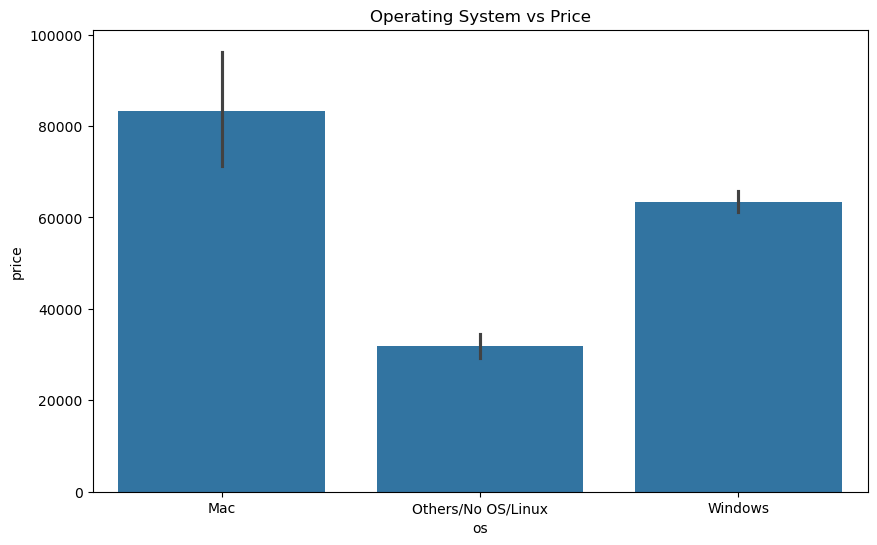

In [50]:
def cat_os(net):
    if net == 'Windows 10' or net == 'Windows 7' or net == 'Windows 10 S':
        return 'Windows'
    elif net == 'macOS' or net == 'Mac OS X':
        return 'Mac'
    else:
        return 'Others/No OS/Linux'

df['os'] = df['opsys'].apply(cat_os)

# حذف العمود القديم
df.drop(columns=['opsys'], inplace=True)

# رسم العلاقة بين نظام التشغيل والسعر
plt.figure(figsize=(10, 6))
sns.barplot(x=df['os'], y=df['price'])
plt.title('Operating System vs Price')
plt.show()

In [51]:
print(df.head())
print("\nFinal Columns List:", df.columns)

  company   typename  ram  weight        price  company_numeric  touchscreen  \
0   apple  Ultrabook    8    1.37   71378.6832                6            0   
1   apple  Ultrabook    8    1.34   47895.5232                6            0   
2      hp   Notebook    8    1.86   30636.0000                3            0   
3   apple  Ultrabook   16    1.83  135195.3360                6            0   
4   apple  Ultrabook    8    1.37   96095.8080                6            0   

   ips         ppi      cpu_brand  ssd  hdd gpu_brand                  os  
0    1  226.983005  Intel Core i5  128    0     Intel                 Mac  
1    0  127.677940  Intel Core i5    0    0     Intel                 Mac  
2    0  141.211998  Intel Core i5  256    0     Intel  Others/No OS/Linux  
3    1  220.534624  Intel Core i7  512    0       AMD                 Mac  
4    1  226.983005  Intel Core i5  256    0     Intel                 Mac  

Final Columns List: Index(['company', 'typename', 'ram', 'weig

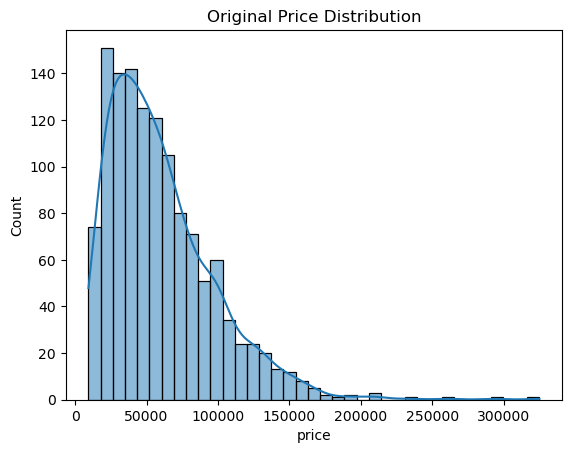

In [53]:
# استخدام histplot بدلاً من distplot
sns.histplot(df['price'], kde=True)
plt.title('Original Price Distribution')
plt.show()

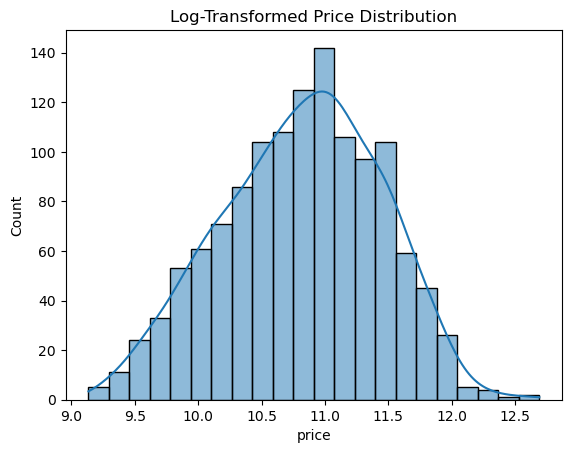

In [54]:
# تطبيق اللوغاريتم على السعر ورسم التوزيع الجديد
sns.histplot(np.log(df['price']), kde=True)
plt.title('Log-Transformed Price Distribution')
plt.show()

In [55]:
# 1. تحديد الـ X والـ y (خد بالك هنستخدم log السعر)
X = df.drop(columns=['price'])
y = np.log(df['price'])

# 2. تقسيم الداتا لتدريب واختبار (Train/Test Split)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=2)

# 3. التأكد من شكل الداتا قبل البدء
print(f"عدد لابتوبات التدريب: {len(X_train)}")
print(f"عدد لابتوبات الاختبار: {len(X_test)}")

عدد لابتوبات التدريب: 1081
عدد لابتوبات الاختبار: 191


In [56]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# 1. تحديد الأعمدة اللي محتاجة تتحول لأرقام (Categorical Columns)
# ملحوظة: اتأكد إن أسماء الأعمدة دي هي اللي موجودة عندك فعلاً
step1 = ColumnTransformer(transformers=[
    ('col_tnf', OneHotEncoder(sparse_output=False, drop='first'), [0, 1, 3, 8, 11])
], remainder='passthrough')

# 2. تعريف الموديل
step2 = LinearRegression()

# 3. دمجهم في Pipeline واحد
pipe = Pipeline([
    ('step1', step1),
    ('step2', step2)
])

# 4. التدريب!
pipe.fit(X_train, y_train)

# 5. التوقع والتقييم
y_pred = pipe.predict(X_test)

print('R2 score:', r2_score(y_test, y_pred))
print('MAE:', mean_absolute_error(y_test, y_pred))

ValueError: could not convert string to float: 'Windows'

In [57]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# 1. تحديد أسماء الأعمدة النصية اللي محتاجة تحويل
categorical_cols = ['company', 'typename', 'cpu_brand', 'gpu_brand', 'os']

# 2. بناء المحول باستخدام الأسماء
step1 = ColumnTransformer(transformers=[
    ('col_tnf', OneHotEncoder(sparse_output=False, drop='first'), categorical_cols)
], remainder='passthrough')

# كمل بقية الـ Pipeline عادي
step2 = LinearRegression()

pipe = Pipeline([
    ('step1', step1),
    ('step2', step2)
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print('R2 score:', r2_score(y_test, y_pred))
print('MAE:', mean_absolute_error(y_test, y_pred))

R2 score: 0.6817502454657637
MAE: 0.2315881660451855


In [58]:
print(X_train.columns)

Index(['company', 'typename', 'ram', 'weight', 'company_numeric',
       'touchscreen', 'ips', 'ppi', 'cpu_brand', 'ssd', 'hdd', 'gpu_brand',
       'os'],
      dtype='object')


In [61]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# 1. الأعمدة النصية فقط هي اللي هتحتاج OneHotEncoder
categorical_cols = ['company', 'typename', 'cpu_brand', 'gpu_brand', 'os']

step1 = ColumnTransformer(transformers=[
    ('col_tnf', OneHotEncoder(sparse_output=False, drop='first'), categorical_cols)
], remainder='passthrough')

# 2. الموديل
step2 = LinearRegression()

# 3. الـ Pipeline
pipe = Pipeline([
    ('step1', step1),
    ('step2', step2)
])

# 4. التدريب على بيانات الـ Log
pipe.fit(X_train, y_train)

# 5. التوقع
y_pred = pipe.predict(X_test)

# 6. النتائج
print('R2 score:', r2_score(y_test, y_pred))
print('MAE:', mean_absolute_error(y_test, y_pred))

R2 score: 0.6817502454657637
MAE: 0.2315881660451855


In [62]:
from sklearn.ensemble import RandomForestRegressor

# 1. نفس المحول اللي استخدمناه (مش هنغير فيه حاجة)
step1 = ColumnTransformer(transformers=[
    ('col_tnf', OneHotEncoder(sparse_output=False, drop='first'), categorical_cols)
], remainder='passthrough')

# 2. الموديل الجديد (Random Forest)
# جرب الإعدادات دي، بتدي نتائج ممتازة في أسعار اللابتوبات
step2 = RandomForestRegressor(n_estimators=100,
                              random_state=3,
                              max_samples=0.5,
                              max_features=0.75,
                              max_depth=15)

pipe = Pipeline([
    ('step1', step1),
    ('step2', step2)
])

# 3. التدريب
pipe.fit(X_train, y_train)

# 4. التوقع والتقييم
y_pred = pipe.predict(X_test)

print('R2 score:', r2_score(y_test, y_pred))
print('MAE:', mean_absolute_error(y_test, y_pred))

R2 score: 0.8278706415710819
MAE: 0.1818390271037753


In [63]:
import pickle

# 1. حفظ الداتا فريم (مهم لو هتعمل واجهة مستخدم)
pickle.dump(df, open('df.pkl', 'wb'))

# 2. حفظ الـ Pipeline (الموديل نفسه)
pickle.dump(pipe, open('pipe.pkl', 'wb'))

print("✅ تم حفظ الموديل بنجاح في ملف pipe.pkl")

✅ تم حفظ الموديل بنجاح في ملف pipe.pkl


In [64]:
# مثال لتوقع سعر لابتوب جديد (خد بالك لازم تبعت نفس شكل الداتا)
# النتيجة هتطلع بالـ log، فلازم نستخدم np.exp عشان نرجعها لأصلها
predicted_log_price = pipe.predict(X_test.iloc[0:1])
actual_price = np.exp(predicted_log_price)

print(f"السعر المتوقع: {actual_price[0]:.2f}")

السعر المتوقع: 37152.77
